In [176]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

trace = "85479ef37b5dc75dd5aeca3bab499129b97a134dac5d740d2c68941de9d63031"
t2 = "734272c01926d19690e5ec308bab64ef97950b75b1c7582283e0783fce1751d8"

df = pd.read_csv(
    "data/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"
)

df["start_timestamp"] = df["end_timestamp"] - df["duration"]
df.head()

,app,func,end_timestamp,duration,start_timestamp
0,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,e3cdb48830f66eb8689cc0223514569a69812b77e6611e...,0.079491,0.078,0.001491
1,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,337cd24a7d5fd5c92460faee4ebe6a186a0eb322bd17b7...,57.157860,57.154,0.003860
2,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,48cc770d590d3c5a7691b3b4e9302f82ec3be5ddc2a037...,59.130478,59.125,0.005478
3,f274d71de386ccc77e4ca74766dbc485461c3053059d47...,3d2aee54a133509f16fb636d74128c2adcfcac71c6dcef...,6.252541,6.236,0.016541
4,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,68bbfd828223a505d7917339f4656c5f33ff93225cdb9d...,0.066824,0.050,0.016824


In [177]:
df2 = df[["app", "start_timestamp"]]
df2 = df2.loc[df2["app"] == trace]

df2["start_timestamp"] = pd.to_timedelta(df2["start_timestamp"], unit="seconds")
df2 = df2.set_index("start_timestamp")

dfc = df2.resample("10min").count()
print(dfc)

                            app
start_timestamp                
0 days 00:00:00.022979113    32
0 days 00:10:00.022979113    28
0 days 00:20:00.022979113    29
0 days 00:30:00.022979113    25
0 days 00:40:00.022979113    35
...                         ...
13 days 23:10:00.022979113   12
13 days 23:20:00.022979113    6
13 days 23:30:00.022979113   18
13 days 23:40:00.022979113    7
13 days 23:50:00.022979113   12

[2016 rows x 1 columns]


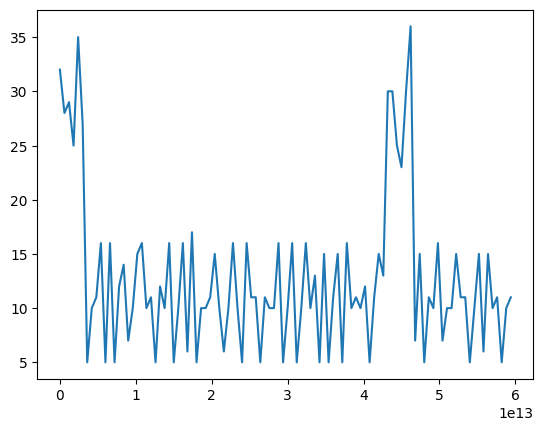

In [178]:
plt.plot(dfc[:100].index, dfc[:100].values)

In [179]:
m = Prophet()
m.fit(dfc)

future = m.make_future_dataframe()
future.tail()

forecast = m.predict(future)

fig1 = m.plot(forecast)


ValueError: Dataframe must have columns "ds" and "y" with the dates and values respectively.